# HB Parameter Recovery Smoke Test

This notebook tests whether the verified HB prior-confidence model can recover parameters from data that the model simulated itself.

Plain-language question:

```text
If these fitted parameters generated fake subject responses, can the same model recover similar parameters when refit to those fake responses?
```

This is a smoke test, not final parameter recovery. It uses the model from `hb_verified_model_implementation.ipynb`, the fitted smoke parameters in `outputs/hb_verified_fit_results_smoke.csv`, and a small subject subset by default.


In [1]:
# Cell purpose: Import libraries and set local paths.

from pathlib import Path
import json
import math
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = PROJECT_ROOT / "data01_direction4priors.csv"
FIT_RESULTS_PATH = OUTPUT_DIR / "hb_verified_fit_results_smoke.csv"

print("data exists:", DATA_PATH.exists(), DATA_PATH)
print("fit results exists:", FIT_RESULTS_PATH.exists(), FIT_RESULTS_PATH)


data exists: True C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\data01_direction4priors.csv
fit results exists: True C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_verified_fit_results_smoke.csv


## Parameter Recovery Logic

The recovery loop has four steps:

```text
1. Take fitted parameters from the verified HB smoke fit.
2. Simulate new estimate_deg values from those parameters.
3. Refit the same model to the simulated estimates.
4. Compare original generating parameters with recovered parameters.
```

Good recovery means recovered values are close to the generating values. Poor recovery means that parameter may not be identifiable from this data/model setup.


In [2]:
# Cell purpose: Define data preparation and circular helpers used by the HB model.

REMOTE_CSV_URL = "https://raw.githubusercontent.com/steevelaquitaine/projInference/refs/heads/gh-pages/data/csv/data01_direction4priors.csv"


def load_trials() -> pd.DataFrame:
    if DATA_PATH.exists():
        return pd.read_csv(DATA_PATH)
    return pd.read_csv(REMOTE_CSV_URL)


def wrap_signed_deg(angle):
    return (np.asarray(angle) + 180.0) % 360.0 - 180.0


def wrap_unsigned_deg(angle):
    return np.asarray(angle) % 360.0


def xy_to_deg(x, y):
    return wrap_unsigned_deg(np.degrees(np.arctan2(y, x)))


def make_angle_grid(start: int = 0, stop: int = 360, step: int = 1) -> np.ndarray:
    return np.arange(start, stop, step, dtype=float)


def normalize_pdf(pdf: np.ndarray, axis: Optional[int] = None) -> np.ndarray:
    pdf = np.asarray(pdf, dtype=float)
    total = np.sum(pdf, axis=axis, keepdims=True)
    return np.divide(pdf, total, out=np.zeros_like(pdf, dtype=float), where=total > 0)


def add_block_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.sort_values(["subject_id", "session_id", "run_id", "trial_index"]).copy()
    block_keys = ["subject_id", "session_id", "run_id", "prior_mean", "prior_std"]
    block_table = out[block_keys].drop_duplicates().reset_index(drop=True)
    block_table["block_id"] = np.arange(1, len(block_table) + 1)
    out = out.merge(block_table, on=block_keys, how="left")
    out["trials_into_block"] = out.groupby("block_id", observed=True).cumcount() + 1
    return out


def build_block_context(df: pd.DataFrame) -> pd.DataFrame:
    block_cols = ["subject_id", "session_id", "run_id", "block_id", "prior_std", "prior_mean"]
    blocks = df[block_cols].drop_duplicates().sort_values(["subject_id", "session_id", "run_id", "block_id"]).reset_index(drop=True)
    blocks["block_order_within_subject"] = blocks.groupby("subject_id", observed=True).cumcount() + 1
    for col in ["block_id", "prior_std", "prior_mean", "session_id", "run_id"]:
        blocks[f"prev_{col}"] = blocks.groupby("subject_id", observed=True)[col].shift(1)
    blocks["same_session_prev"] = blocks["session_id"].eq(blocks["prev_session_id"])
    blocks["prior_std_change"] = blocks["prior_std"] - blocks["prev_prior_std"]
    return blocks


def add_block_context(df: pd.DataFrame) -> pd.DataFrame:
    blocks = build_block_context(df)
    keep = ["block_id", "block_order_within_subject", "prev_block_id", "prev_prior_std", "prev_prior_mean", "same_session_prev", "prior_std_change"]
    return df.merge(blocks[keep], on="block_id", how="left")


def add_circular_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["estimate_deg"] = xy_to_deg(out["estimate_x"], out["estimate_y"])
    out["error_from_motion"] = wrap_signed_deg(out["estimate_deg"] - out["motion_direction"])
    out["abs_error_from_motion"] = np.abs(out["error_from_motion"])
    out["motion_offset_from_prior"] = wrap_signed_deg(out["motion_direction"] - out["prior_mean"])
    out["estimate_offset_from_prior"] = wrap_signed_deg(out["estimate_deg"] - out["prior_mean"])
    return out


def prepare_trials(df: pd.DataFrame) -> pd.DataFrame:
    out = add_block_id(df)
    out = add_block_context(out)
    out = add_circular_columns(out)
    return out.sort_values(["subject_id", "session_id", "run_id", "trial_index"]).reset_index(drop=True)


def make_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "subject_id", "session_id", "run_id", "trial_index", "block_id", "trials_into_block",
        "motion_direction", "motion_coherence", "prior_std", "prior_mean", "estimate_deg",
        "error_from_motion", "abs_error_from_motion", "motion_offset_from_prior", "estimate_offset_from_prior",
        "prev_prior_std", "prev_prior_mean", "same_session_prev", "prior_std_change",
    ]
    return df[cols].copy()


raw = load_trials()
trials = prepare_trials(raw)
model_df = make_model_frame(trials)
fit_results = pd.read_csv(FIT_RESULTS_PATH)

print("raw:", raw.shape)
print("model_df:", model_df.shape)
print("fit_results:", fit_results.shape)


raw: (83213, 16)
model_df: (83213, 19)
fit_results: (12, 14)


In [3]:
# Cell purpose: Define the same fitted HB model used in the verified implementation notebook.

HB_MAX_LAPSE = 0.25


def _inv_logit(x: float) -> float:
    return float(1.0 / (1.0 + np.exp(-x)))


def _safe_logit(p: float) -> float:
    p = float(np.clip(p, 1e-6, 1.0 - 1e-6))
    return float(np.log(p / (1.0 - p)))


def parse_param_map(text: str) -> dict[float, float]:
    return {float(k): float(v) for k, v in json.loads(text).items()}


def params_from_fit_row(row: pd.Series) -> dict:
    return {
        "k_llh_by_coherence": parse_param_map(row["k_llh_by_coherence"]),
        "k_prior_target_by_std": parse_param_map(row["k_prior_target_by_std"]),
        "carryover_weight": float(row["carryover_weight"]),
        "learning_tau": float(row["learning_tau"]),
        "k_motor": float(row["k_motor"]),
        "lapse_rate": float(row["lapse_rate"]),
    }


def hb_param_levels(df: pd.DataFrame) -> tuple[tuple[float, ...], tuple[float, ...]]:
    coherences = tuple(float(x) for x in sorted(df["motion_coherence"].dropna().unique()))
    prior_stds = tuple(float(x) for x in sorted(df["prior_std"].dropna().unique()))
    return coherences, prior_stds


def kappa_from_sd_deg(sd_deg: float, floor: float = 1e-3) -> float:
    sd_rad = np.deg2rad(max(float(sd_deg), floor))
    return 1.0 / (sd_rad ** 2)


def hb_initial_vector(df: pd.DataFrame) -> np.ndarray:
    coherences, prior_stds = hb_param_levels(df)
    k_llh_start = [max(0.05, 4.0 + 80.0 * coh) for coh in coherences]
    k_prior_start = [max(0.05, kappa_from_sd_deg(sd)) for sd in prior_stds]
    return np.array(
        [np.log(x) for x in k_llh_start]
        + [np.log(x) for x in k_prior_start]
        + [_safe_logit(0.35)]
        + [np.log(45.0)]
        + [np.log(80.0)]
        + [_safe_logit(0.02 / HB_MAX_LAPSE)],
        dtype=float,
    )


def hb_bounds(df: pd.DataFrame) -> list[tuple[float, float]]:
    coherences, prior_stds = hb_param_levels(df)
    bounds = []
    bounds.extend([(np.log(0.05), np.log(140.0)) for _ in coherences])
    bounds.extend([(np.log(0.03), np.log(140.0)) for _ in prior_stds])
    bounds.append((_safe_logit(0.01), _safe_logit(0.99)))
    bounds.append((np.log(2.0), np.log(250.0)))
    bounds.append((np.log(1.0), np.log(400.0)))
    bounds.append((_safe_logit(0.0005 / HB_MAX_LAPSE), _safe_logit(0.95)))
    return bounds


def hb_unpack_params(theta: np.ndarray, df: pd.DataFrame) -> dict:
    coherences, prior_stds = hb_param_levels(df)
    theta = np.asarray(theta, dtype=float)
    i = 0
    k_llh = {coh: float(np.exp(theta[i + j])) for j, coh in enumerate(coherences)}
    i += len(coherences)
    k_prior_target = {sd: float(np.exp(theta[i + j])) for j, sd in enumerate(prior_stds)}
    i += len(prior_stds)
    carryover_weight = _inv_logit(theta[i]); i += 1
    learning_tau = float(np.exp(theta[i])); i += 1
    k_motor = float(np.exp(theta[i])); i += 1
    lapse_rate = float(HB_MAX_LAPSE * _inv_logit(theta[i]))
    return {
        "k_llh_by_coherence": k_llh,
        "k_prior_target_by_std": k_prior_target,
        "carryover_weight": carryover_weight,
        "learning_tau": learning_tau,
        "k_motor": k_motor,
        "lapse_rate": lapse_rate,
    }


def hb_sort_subject_trials(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(["subject_id", "session_id", "run_id", "trial_index"]).reset_index(drop=True)


def hb_block_balanced_subset(d: pd.DataFrame, max_trials: Optional[int]) -> pd.DataFrame:
    d = hb_sort_subject_trials(d)
    if max_trials is None or len(d) <= int(max_trials):
        return d.reset_index(drop=True)
    block_count = max(int(d["block_id"].nunique()), 1)
    n_per_block = max(1, int(np.ceil(int(max_trials) / block_count)))
    subset = (
        d.groupby("block_id", observed=True, group_keys=False)
        .head(n_per_block)
        .sort_values(["subject_id", "session_id", "run_id", "trial_index"])
        .reset_index(drop=True)
    )
    if len(subset) > int(max_trials):
        keep = np.unique(np.linspace(0, len(subset) - 1, int(max_trials)).round().astype(int))
        subset = subset.iloc[keep].copy()
    return subset.reset_index(drop=True)


def hb_prepare_subject_fit_data(df: pd.DataFrame, subject_id: int, max_trials: Optional[int] = None) -> pd.DataFrame:
    d = hb_sort_subject_trials(df[df["subject_id"] == subject_id]).copy()
    return hb_block_balanced_subset(d, max_trials=max_trials)


def hb_prior_confidence_path(subject_df: pd.DataFrame, params: dict) -> np.ndarray:
    d = hb_sort_subject_trials(subject_df)
    targets = d["prior_std"].astype(float).map(params["k_prior_target_by_std"]).to_numpy(dtype=float)
    previous_targets = []
    for current_sd, prev_sd in zip(d["prior_std"].astype(float), d["prev_prior_std"]):
        if pd.isna(prev_sd):
            previous_targets.append(params["k_prior_target_by_std"][float(current_sd)])
        else:
            previous_targets.append(params["k_prior_target_by_std"].get(float(prev_sd), params["k_prior_target_by_std"][float(current_sd)]))
    previous_targets = np.asarray(previous_targets, dtype=float)
    carry = params["carryover_weight"]
    initial = carry * previous_targets + (1.0 - carry) * targets
    trial_pos = np.maximum(d["trials_into_block"].to_numpy(dtype=float) - 1.0, 0.0)
    progress = 1.0 - np.exp(-trial_pos / max(params["learning_tau"], 1e-6))
    return np.clip(initial + progress * (targets - initial), 1e-6, None)


def hb_vm_pdf_matrix(angle_grid: np.ndarray, centers_deg: np.ndarray, kappas: np.ndarray) -> np.ndarray:
    grid = np.asarray(angle_grid, dtype=float).reshape(1, -1)
    centers = np.asarray(centers_deg, dtype=float).reshape(-1, 1)
    kappas = np.asarray(kappas, dtype=float).reshape(-1, 1)
    delta_rad = np.deg2rad(wrap_signed_deg(grid - centers))
    log_pdf = kappas * (np.cos(delta_rad) - 1.0)
    pdf = np.exp(log_pdf - np.nanmax(log_pdf, axis=1, keepdims=True))
    return normalize_pdf(pdf, axis=1)


def hb_circular_readout(angle_grid: np.ndarray, posterior: np.ndarray, readout: str = "MAP") -> np.ndarray:
    readout = readout.upper()
    if readout == "MAP":
        return angle_grid[np.argmax(posterior, axis=1)]
    if readout == "BLS":
        theta = np.deg2rad(angle_grid)
        z = np.sum(posterior * np.exp(1j * theta.reshape(1, -1)), axis=1)
        return np.degrees(np.angle(z)) % 360.0
    raise ValueError("This notebook supports MAP or BLS readout.")


def hb_motor_probability(angle_grid: np.ndarray, observed_deg: np.ndarray, predicted_deg: np.ndarray, k_motor: float) -> np.ndarray:
    delta = wrap_signed_deg(np.asarray(observed_deg, dtype=float) - np.asarray(predicted_deg, dtype=float))
    numerator = np.exp(k_motor * (np.cos(np.deg2rad(delta)) - 1.0))
    kernel = np.exp(k_motor * (np.cos(np.deg2rad(wrap_signed_deg(angle_grid))) - 1.0))
    return numerator / np.sum(kernel)


def hb_predict_subject(subject_df: pd.DataFrame, params: dict, readout: str = "MAP") -> pd.DataFrame:
    d = hb_sort_subject_trials(subject_df).copy()
    angle_grid = make_angle_grid()
    k_llh = d["motion_coherence"].astype(float).map(params["k_llh_by_coherence"]).to_numpy(dtype=float)
    k_prior_t = hb_prior_confidence_path(d, params)
    likelihood = hb_vm_pdf_matrix(angle_grid, d["motion_direction"].to_numpy(dtype=float), k_llh)
    prior = hb_vm_pdf_matrix(angle_grid, d["prior_mean"].to_numpy(dtype=float), k_prior_t)
    posterior = normalize_pdf(likelihood * prior, axis=1)
    predicted_deg = hb_circular_readout(angle_grid, posterior, readout=readout)
    motor_prob = hb_motor_probability(angle_grid, d["estimate_deg"].to_numpy(dtype=float), predicted_deg, params["k_motor"])
    p_observed = (1.0 - params["lapse_rate"]) * motor_prob + params["lapse_rate"] / len(angle_grid)
    return pd.DataFrame({
        "subject_id": d["subject_id"].to_numpy(),
        "session_id": d["session_id"].to_numpy(),
        "run_id": d["run_id"].to_numpy(),
        "trial_index": d["trial_index"].to_numpy(),
        "motion_direction": d["motion_direction"].to_numpy(dtype=float),
        "estimate_deg": d["estimate_deg"].to_numpy(dtype=float),
        "prior_mean": d["prior_mean"].to_numpy(dtype=float),
        "prior_std": d["prior_std"].to_numpy(dtype=float),
        "motion_coherence": d["motion_coherence"].to_numpy(dtype=float),
        "prior_kappa_t": k_prior_t,
        "predicted_estimate_deg": predicted_deg,
        "p_observed": np.clip(p_observed, 1e-320, None),
        "observed_error_from_motion": wrap_signed_deg(d["estimate_deg"].to_numpy(dtype=float) - d["motion_direction"].to_numpy(dtype=float)),
        "predicted_error_from_motion": wrap_signed_deg(predicted_deg - d["motion_direction"].to_numpy(dtype=float)),
    })


def hb_subject_nll(theta: np.ndarray, subject_df: pd.DataFrame, readout: str = "MAP") -> float:
    params = hb_unpack_params(theta, subject_df)
    pred = hb_predict_subject(subject_df, params, readout=readout)
    value = float(-np.sum(np.log(np.clip(pred["p_observed"].to_numpy(dtype=float), 1e-320, None))))
    return value if np.isfinite(value) else 1e100


def fit_subject_hb(df: pd.DataFrame, subject_id: int, max_trials: Optional[int] = 360, maxiter: int = 15, readout: str = "MAP") -> tuple[dict, pd.DataFrame]:
    d = hb_prepare_subject_fit_data(df, subject_id=subject_id, max_trials=max_trials)
    result = minimize(
        hb_subject_nll,
        hb_initial_vector(d),
        args=(d, readout),
        method="Powell",
        bounds=hb_bounds(d),
        options={"maxiter": int(maxiter), "xtol": 1e-3, "ftol": 1e-4},
    )
    params = hb_unpack_params(result.x, d)
    pred = hb_predict_subject(d, params, readout=readout)
    fit_row = {
        "subject_id": int(subject_id),
        "readout": readout,
        "n_trials_fit": int(len(d)),
        "nll": float(result.fun),
        "nll_per_trial": float(result.fun / max(len(d), 1)),
        "optimizer_success": bool(result.success),
        "optimizer_status": int(result.status),
        "optimizer_message": str(result.message),
        "carryover_weight": params["carryover_weight"],
        "learning_tau": params["learning_tau"],
        "k_motor": params["k_motor"],
        "lapse_rate": params["lapse_rate"],
        "k_llh_by_coherence": json.dumps(params["k_llh_by_coherence"], sort_keys=True),
        "k_prior_target_by_std": json.dumps(params["k_prior_target_by_std"], sort_keys=True),
    }
    return fit_row, pred


In [4]:
# Cell purpose: Simulate fake estimates from fitted parameters.

rng = np.random.default_rng(20260717)


def simulate_estimates_from_params(subject_df: pd.DataFrame, params: dict, rng: np.random.Generator, readout: str = "MAP") -> pd.DataFrame:
    pred = hb_predict_subject(subject_df, params, readout=readout)
    predicted = pred["predicted_estimate_deg"].to_numpy(dtype=float)
    n = len(predicted)
    is_lapse = rng.random(n) < params["lapse_rate"]
    simulated = np.empty(n, dtype=float)
    simulated[is_lapse] = rng.uniform(0.0, 360.0, size=int(is_lapse.sum()))
    if (~is_lapse).any():
        motor_rad = rng.vonmises(mu=np.deg2rad(predicted[~is_lapse]), kappa=params["k_motor"])
        simulated[~is_lapse] = np.degrees(motor_rad) % 360.0
    sim = subject_df.copy().reset_index(drop=True)
    sim["original_estimate_deg"] = sim["estimate_deg"].to_numpy(dtype=float)
    sim["estimate_deg"] = simulated
    sim["simulated_error_from_motion"] = wrap_signed_deg(sim["estimate_deg"] - sim["motion_direction"])
    sim["simulated_from_predicted_estimate_deg"] = predicted
    sim["simulated_is_lapse"] = is_lapse
    return sim


In [5]:
# Cell purpose: Run a small parameter-recovery smoke test on selected subjects.

RECOVERY_SUBJECT_IDS = [1, 2, 3]
RECOVERY_MAX_TRIALS_PER_SUBJECT = 360
RECOVERY_MAXITER = 15
RECOVERY_READOUT = "MAP"

recovery_fit_rows = []
simulated_frames = []

for subject_id in RECOVERY_SUBJECT_IDS:
    base_subject = hb_prepare_subject_fit_data(model_df, subject_id, max_trials=RECOVERY_MAX_TRIALS_PER_SUBJECT)
    generating_row = fit_results.loc[fit_results["subject_id"] == subject_id].iloc[0]
    generating_params = params_from_fit_row(generating_row)
    simulated_subject = simulate_estimates_from_params(base_subject, generating_params, rng=rng, readout=RECOVERY_READOUT)
    recovered_row, recovered_pred = fit_subject_hb(
        simulated_subject,
        subject_id=subject_id,
        max_trials=None,
        maxiter=RECOVERY_MAXITER,
        readout=RECOVERY_READOUT,
    )
    recovered_row["recovery_source"] = "simulated_from_hb_verified_smoke_fit"
    recovery_fit_rows.append(recovered_row)
    simulated_frames.append(simulated_subject.assign(recovery_subject_id=subject_id))
    print(f"subject {subject_id}: recovered NLL={recovered_row['nll']:.2f}, success={recovered_row['optimizer_success']}")

recovery_fit_results = pd.DataFrame(recovery_fit_rows)
recovery_simulated_trials = pd.concat(simulated_frames, ignore_index=True)

display(recovery_fit_results)
display(recovery_simulated_trials.head())


subject 1: recovered NLL=1699.22, success=True


subject 2: recovered NLL=1553.09, success=True


subject 3: recovered NLL=1701.67, success=True


,subject_id,readout,n_trials_fit,nll,nll_per_trial,optimizer_success,optimizer_status,optimizer_message,carryover_weight,learning_tau,k_motor,lapse_rate,k_llh_by_coherence,k_prior_target_by_std,recovery_source
0,1,MAP,360,1699.222679,4.720063,True,0,Optimization terminated successfully.,0.129756,114.662745,12.073880,0.130144,"{""0.06"": 13.39934445590873, ""0.12"": 30.6676496...","{""10.0"": 20.73136146112447, ""20.0"": 34.1719821...",simulated_from_hb_verified_smoke_fit
1,2,MAP,360,1553.085475,4.314126,True,0,Optimization terminated successfully.,0.020510,39.557678,30.477595,0.125290,"{""0.06"": 0.1076762131031198, ""0.12"": 0.1352389...","{""10.0"": 3.0210584582246502, ""20.0"": 15.337511...",simulated_from_hb_verified_smoke_fit
2,3,MAP,360,1701.667476,4.726854,True,0,Optimization terminated successfully.,0.747470,38.552032,15.110827,0.168934,"{""0.06"": 0.3707371344721684, ""0.12"": 6.6511855...","{""10.0"": 2.787829006263073, ""20.0"": 0.72922676...",simulated_from_hb_verified_smoke_fit


,subject_id,session_id,run_id,trial_index,block_id,trials_into_block,motion_direction,motion_coherence,prior_std,prior_mean,...,estimate_offset_from_prior,prev_prior_std,prev_prior_mean,same_session_prev,prior_std_change,original_estimate_deg,simulated_error_from_motion,simulated_from_predicted_estimate_deg,simulated_is_lapse,recovery_subject_id
0,1,1,1,1,1,1,225,0.12,10,225,...,0.583113,NaN,NaN,False,NaN,225.583113,-2.051688,225.0,False,1
1,1,1,1,2,1,2,225,0.12,10,225,...,-1.708718,NaN,NaN,False,NaN,223.291282,2.656554,225.0,False,1
2,1,1,1,3,1,3,235,0.06,10,225,...,6.312691,NaN,NaN,False,NaN,231.312691,12.039885,226.0,False,1
3,1,1,1,4,1,4,225,0.06,10,225,...,5.166776,NaN,NaN,False,NaN,230.166776,4.743924,225.0,True,1
4,1,1,1,5,1,5,215,0.24,10,225,...,4.020860,NaN,NaN,False,NaN,229.020860,40.558446,222.0,False,1


In [6]:
# Cell purpose: Compare generating parameters with recovered parameters.


def flatten_core_params(row: pd.Series, prefix: str) -> dict:
    params = params_from_fit_row(row)
    flat = {
        f"{prefix}:carryover_weight": params["carryover_weight"],
        f"{prefix}:learning_tau": params["learning_tau"],
        f"{prefix}:k_motor": params["k_motor"],
        f"{prefix}:lapse_rate": params["lapse_rate"],
    }
    for coh, value in params["k_llh_by_coherence"].items():
        flat[f"{prefix}:k_llh_coh_{coh}"] = value
    for sd, value in params["k_prior_target_by_std"].items():
        flat[f"{prefix}:k_prior_std_{sd}"] = value
    return flat

comparison_rows = []
for subject_id in RECOVERY_SUBJECT_IDS:
    generating_row = fit_results.loc[fit_results["subject_id"] == subject_id].iloc[0]
    recovered_row = recovery_fit_results.loc[recovery_fit_results["subject_id"] == subject_id].iloc[0]
    gen = flatten_core_params(generating_row, "generating")
    rec = flatten_core_params(recovered_row, "recovered")
    parameter_names = sorted(k.replace("generating:", "") for k in gen)
    for name in parameter_names:
        gen_value = gen.get(f"generating:{name}", np.nan)
        rec_value = rec.get(f"recovered:{name}", np.nan)
        comparison_rows.append({
            "subject_id": subject_id,
            "parameter": name,
            "generating_value": gen_value,
            "recovered_value": rec_value,
            "absolute_error": abs(rec_value - gen_value) if pd.notna(rec_value) and pd.notna(gen_value) else np.nan,
            "log_ratio_recovered_over_generating": np.log((rec_value + 1e-9) / (gen_value + 1e-9)) if pd.notna(rec_value) and pd.notna(gen_value) else np.nan,
        })

parameter_recovery_summary = pd.DataFrame(comparison_rows)
parameter_recovery_summary_path = OUTPUT_DIR / "hb_parameter_recovery_smoke_summary.csv"
recovery_fit_results_path = OUTPUT_DIR / "hb_parameter_recovery_smoke_fit_results.csv"
recovery_simulated_trials_path = OUTPUT_DIR / "hb_parameter_recovery_smoke_simulated_trials.csv"

parameter_recovery_summary.to_csv(parameter_recovery_summary_path, index=False)
recovery_fit_results.to_csv(recovery_fit_results_path, index=False)
recovery_simulated_trials.to_csv(recovery_simulated_trials_path, index=False)

print("saved:", parameter_recovery_summary_path)
print("saved:", recovery_fit_results_path)
print("saved:", recovery_simulated_trials_path)
display(parameter_recovery_summary.head(20))


saved: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_parameter_recovery_smoke_summary.csv
saved: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_parameter_recovery_smoke_fit_results.csv
saved: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_parameter_recovery_smoke_simulated_trials.csv


,subject_id,parameter,generating_value,recovered_value,absolute_error,log_ratio_recovered_over_generating
0,1,carryover_weight,0.027293,0.129756,0.102463,1.559010
1,1,k_llh_coh_0.06,3.722589,13.399344,9.676756,1.280786
2,1,k_llh_coh_0.12,10.746463,30.667650,19.921186,1.048632
3,1,k_llh_coh_0.24,19.656426,49.478371,29.821945,0.923131
4,1,k_motor,11.986870,12.073880,0.087010,0.007233
5,1,k_prior_std_10.0,40.254961,20.731361,19.523599,-0.663586
6,1,k_prior_std_20.0,11.652534,34.171982,22.519448,1.075882
7,1,k_prior_std_40.0,2.150809,4.446769,2.295959,0.726333
8,1,k_prior_std_80.0,1.492750,5.611569,4.118818,1.324210
9,1,lapse_rate,0.123385,0.130144,0.006759,0.053330


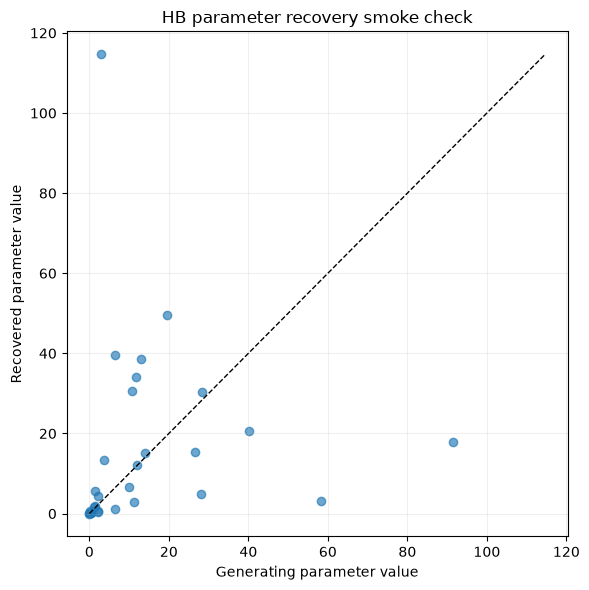

,parameter,n,mean_abs_error,median_abs_log_ratio
4,k_motor,3,1.099185,0.071457
9,lapse_rate,3,0.018312,0.079010
7,k_prior_std_40.0,3,1.441983,0.726333
2,k_llh_coh_0.12,3,7.829122,1.048632
6,k_prior_std_20.0,3,11.755550,1.063330
1,k_llh_coh_0.06,3,3.389486,1.280786
8,k_prior_std_80.0,3,3.267029,1.324210
5,k_prior_std_10.0,3,27.715987,1.389669
0,carryover_weight,3,0.259495,1.559010
3,k_llh_coh_0.24,3,42.132629,1.625281


In [7]:
# Cell purpose: Plot generating versus recovered parameters for the smoke recovery check.

plot_df = parameter_recovery_summary.dropna(subset=["generating_value", "recovered_value"]).copy()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(plot_df["generating_value"], plot_df["recovered_value"], alpha=0.65)
lo = min(plot_df["generating_value"].min(), plot_df["recovered_value"].min())
hi = max(plot_df["generating_value"].max(), plot_df["recovered_value"].max())
ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Generating parameter value")
ax.set_ylabel("Recovered parameter value")
ax.set_title("HB parameter recovery smoke check")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

recovery_quality = (
    parameter_recovery_summary.groupby("parameter", observed=True)
    .agg(
        n=("absolute_error", "size"),
        mean_abs_error=("absolute_error", "mean"),
        median_abs_log_ratio=("log_ratio_recovered_over_generating", lambda x: float(np.nanmedian(np.abs(x)))),
    )
    .reset_index()
    .sort_values("median_abs_log_ratio")
)
display(recovery_quality)


## How To Interpret This Smoke Recovery

If points fall near the diagonal in the plot, the model can recover those generating parameters in this small simulation.

If parameters are far from the diagonal, the smoke test is warning us that those parameters may be hard to identify under the current simplified likelihood, subset size, optimizer settings, or MAP readout.

This notebook is the first recovery implementation. The final version should run more subjects, more trials, and multiple random restarts.
